In [4]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
data_promo= {
    'Experience_Years':[2,4,5,3,6,5],
    'Performance_Rating':[3,4,5,3,4,4],
    'Promoted':['No','Yes','Yes','No','Yes',None]}

df = pd.DataFrame(data_promo)
print('Dataset:')
display(df)
    

Dataset:


,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,5,5,Yes
3,3,3,No
4,6,4,Yes
5,5,4,None


In [10]:
# Clean the data
train_df=df.dropna()

In [11]:
train_df

,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,5,5,Yes
3,3,3,No
4,6,4,Yes


In [14]:
# split the data to find out input & output
X= train_df[['Experience_Years','Performance_Rating']]
y= train_df['Promoted']

In [15]:
# create the model
model= DecisionTreeClassifier()

In [16]:
# train the model
model.fit(X,y)

DecisionTreeClassifier()

In [23]:
# Predict
pred= model.predict([[5,4]])
print('Promotion Prediction:',pred[0])

Promotion Prediction: Yes


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


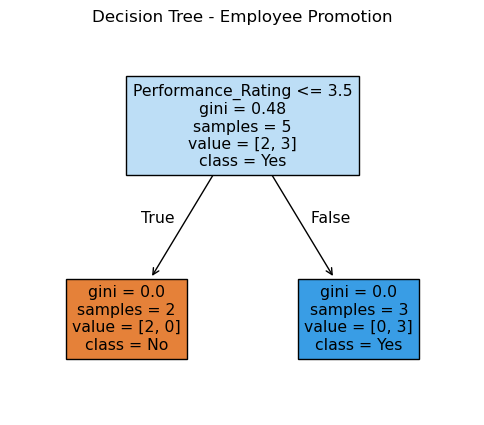

In [27]:
# Visualize decision tree
plt.figure(figsize=(6,5))
plot_tree(model,
          feature_names=['Experience_Years','Performance_Rating'],  # fixed typo
          class_names=['No','Yes'],
          filled=True)
plt.title('Decision Tree - Employee Promotion')  # fixed typo
plt.show()            
                        
                        
           

In [49]:
# Take the exp. years and performance rating from user and display Promoted or Not Promoted using prediction
# Write code in this way, there should be no warning message 
# exp_years
# per_rating=
# print('Promoted?',)

In [50]:
new_exp= int(input('Enter Staff Experience:'))
new_perf= int(input('Enter Performance Rating:'))
pred_pro= model.predict(pd.DataFrame([[new_exp, new_perf]], columns=['Experience_Years', 'Performance_Rating']))
print(f'Experience year: {new_exp} Performance rating: {new_perf} \nPromotion prediction: {pred_pro[0]}')

Enter Staff Experience: 8
Enter Performance Rating: 9


Experience year: 8 Performance rating: 9 
Promotion prediction: Yes


In [43]:
# One more exercise example on DecisionTreeClassifier

In [45]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [48]:
data= { 'Age': [25,30,45,35,22,40,50],
       'Income': ['Low','Medium','High','Medium','Low','High','High'],
       'Buy': ['No','No','Yes','Yes','No','Yes','Yes']}

In [55]:
# One more example on DecisionTreeClassifier

In [56]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt

In [59]:
data = {
    'Age': [25, 30, 45, 35, 22, 40, 50],
    'Income': ['Low', 'Medium', 'High', 'Medium', 'Low', 'High', 'High'],
    'Buy': ['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes']}

df=pd.DataFrame(data)
df

,Age,Income,Buy
0,25,Low,No
1,30,Medium,No
2,45,High,Yes
3,35,Medium,Yes
4,22,Low,No
5,40,High,Yes
6,50,High,Yes


In [65]:
# OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
income_encoded = encoder.fit_transform(df[['Income']])
income_encoded_df = pd.DataFrame(income_encoded, columns=encoder.get_feature_names_out(['Income']))
income_encoded_df                                

,Income_High,Income_Low,Income_Medium
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0
5,1.0,0.0,0.0
6,1.0,0.0,0.0


In [66]:
# LabelEncoder
label_encoder = LabelEncoder()
df['Buy'] = label_encoder.fit_transform(df['Buy'])
df['Buy']
                                   

0    0
1    0
2    1
3    1
4    0
5    1
6    1
Name: Buy, dtype: int64

In [69]:
income_encoded = encoder.fit_transform(df[['Income']])
income_encoder_df = pd.DataFrame(income_encoded, columns=encoder.get_feature_names_out(['Income']))
df_encoded = pd.concat([df[['Age', 'Buy']], income_encoder_df], axis=1)
df_encoded

,Age,Buy,Income_High,Income_Low,Income_Medium
0,25,0,0.0,1.0,0.0
1,30,0,0.0,0.0,1.0
2,45,1,1.0,0.0,0.0
3,35,1,0.0,0.0,1.0
4,22,0,0.0,1.0,0.0
5,40,1,1.0,0.0,0.0
6,50,1,1.0,0.0,0.0


In [71]:
# split data
X = df_encoded.drop('Buy', axis=1)
y= df_encoded['Buy']
X,y

(   Age  Income_High  Income_Low  Income_Medium
 0   25          0.0         1.0            0.0
 1   30          0.0         0.0            1.0
 2   45          1.0         0.0            0.0
 3   35          0.0         0.0            1.0
 4   22          0.0         1.0            0.0
 5   40          1.0         0.0            0.0
 6   50          1.0         0.0            0.0,
 0    0
 1    0
 2    1
 3    1
 4    0
 5    1
 6    1
 Name: Buy, dtype: int64)

In [72]:
# create the model
model= DecisionTreeClassifier()

In [73]:
# train the model
model.fit(X,y)

DecisionTreeClassifier()

In [90]:
sample=pd.DataFrame({'Age':[28], 'Income':['High']})
sample_encoded= encoder.transform(sample[['Income']])

sample_encoder_df= pd.DataFrame(sample_encoded, columns= encoder.get_feature_names_out(['Income']))

sample_final = pd.concat([sample[['Age']], sample_encoder_df], axis=1)

prediction= model.predict(sample_final)
predicted_label= label_encoder.inverse_transform(prediction)

print('Prediction for Age=28, Income=Medium➜',predicted_label[0])

Prediction for Age=28, Income=Medium➜ 0


In [91]:
person_age=int(input('Enter Age'))
person_income=input('enter category Low, Medium or High')
person=pd.DataFrame({'Age': [person_age], 'Income':[person_income]})

person_encoded= encoder.transform(person[['Income']])
person_encoded_df= pd.DataFrame(person_encoded, columns= encoder.get_feature_names_out(['Income']))
person_final = pd.concat([sample[['Age']], person_encoded_df], axis=1)

prediction= model.predict(person_final)
predicted_label= label_encoder.inverse_transform(prediction)

print(f'Prediction for Age={person_age}, Income={person_income}➜',predicted_label[0])

Enter Age 23
enter category Low, Medium or High High


Prediction for Age=23, Income=High➜ 0


In [92]:
#